# Exercise 3

In this exercise, you will analyse a dataset obtained from the London transport system (TfL). The data is in a filled called `tfl_readership.csv` (comma-separated-values format).  As in Exercise 2, we will load and view the data using  `pandas`. 

In [1]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load data
df_tfl = pd.read_csv('tfl_ridership.csv')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/tfl_ridership.csv'

df_tfl.head(13)

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
0,2000/01,P 01,01 Apr '00,29 Apr '00,29d,884,0,0,210,231,...,0,655,1066,200,2509,0,0,96,45.8,0.0
1,2000/01,P 02,30 Apr '00,27 May '00,28d,949,0,0,214,205,...,0,605,1168,217,2598,0,0,93,46.5,0.0
2,2000/01,P 03,28 May '00,24 Jun '00,28d,945,0,0,209,221,...,0,650,1154,212,2623,0,0,98,47.1,0.0
3,2000/01,P 04,25 Jun '00,22 Jul '00,28d,981,0,0,216,241,...,0,708,1196,214,2761,0,0,105,50.8,0.0
4,2000/01,P 05,23 Jul '00,19 Aug '00,28d,958,0,0,225,248,...,0,730,1165,165,2643,0,0,103,50.3,0.0
5,2000/01,P 06,20 Aug '00,16 Sep '00,28d,984,0,0,243,236,...,0,702,1164,151,2608,0,0,100,49.2,0.0
6,2000/01,P 07,17 Sep '00,14 Oct '00,28d,1001,0,0,205,216,...,0,639,1286,196,2763,0,0,107,48.8,0.0
7,2000/01,P 08,15 Oct '00,11 Nov '00,28d,979,0,0,199,221,...,0,668,1298,220,2819,0,0,113,51.5,0.0
8,2000/01,P 09,12 Nov '00,09 Dec '00,28d,971,0,0,184,212,...,0,640,1302,242,2839,0,0,114,54.0,0.0
9,2000/01,P 10,10 Dec '00,06 Jan '01,28d,912,0,0,192,211,...,0,631,993,195,2359,0,0,90,55.3,0.0


Each row of our data frame represents the average daily ridership over a 28/29 day period for various types of transport and tickets (bus, tube etc.).  We have used the `.head()` command to display the top 13 rows of the data frame (corresponding to one year).  Focusing on the "Tube Total" column, notice the dip in ridership in row 9 (presumably due to Christmas/New Year's), and also the slight dip during the summer (rows 4,5).

In [3]:
#df_tfl.sample(3)  #random sample of 3 rows
df_tfl.tail(3)  #last 3 rows

,Year,Period,Start,End,Days,Bus cash (000s),Bus Oyster PAYG (000s),Bus Contactless (000s),Bus One Day Bus Pass (000s),Bus Day Travelcard (000s),...,Tube Contactless (000s),Tube Day Travelcard (000s),Tube Season Travelcard (000s),Tube Other incl free (000s),Tube Total (000s),TfL Rail (000s),Overground (000s),DLR (000s),Tram (000s),Air Line (000s)
242,2018/19,P 09,11 Nov '18,08 Dec '18,28d,0,1110,1089,0,41,...,1399,249,1017,334,4221,996,557,355,84.1,2.6
243,2018/19,P 10,09 Dec '18,05 Jan '19,28d,0,1001,949,0,38,...,1110,242,632,259,3279,750,414,270,66.3,3.2
244,2018/19,P 11,06 Jan '19,02 Feb '19,28d,0,1036,1075,0,30,...,1310,204,924,305,3809,929,517,333,79.3,2.3


The dataframe contains $N=245$ counting periods (of 28/29 days each) from 1 April 2000 to  2 Feb 2019. We now define a numpy array consisting of the values in the ' Tube Total (000s)' column:

In [4]:
yvals = np.array(df_tfl['Tube Total (000s)'])
N = np.size(yvals)
xvals = np.linspace(1,N,N) #an array containing the values 1,2....,N

We now have a time series consisting of points $(x_i,y_i)$, for $i = 1, \ldots, N$, where $y_i$ is the average daily tube rideship in counting period $x_i = i$.

## 3a) Plot the data in a scatterplot

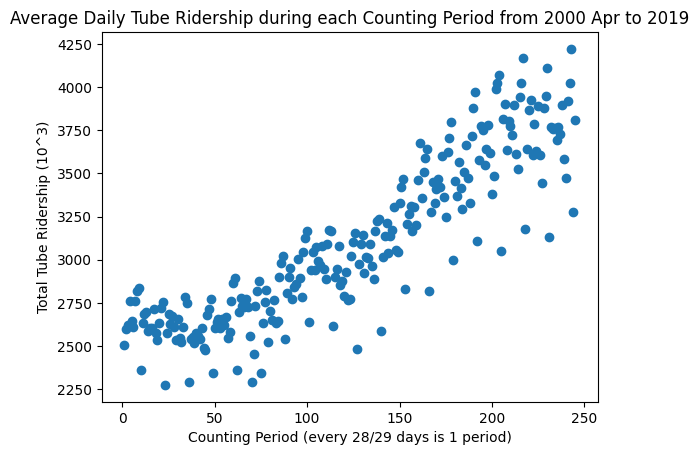

In [7]:
#Your code for scatterplot here
plt.scatter(xvals, yvals)
plt.xlabel('Counting Period (every 28/29 days is 1 period)')
plt.ylabel('Total Tube Ridership (10^3)')
plt.title("Average Daily Tube Ridership during each Counting Period from 2000 Apr to 2019")
plt.show()


## 3b) Fit a linear model $f(x) = \beta_0 + \beta_1 x$ to the data

- Print the values of the regression coefficients $\beta_0, \beta_1$ determined using least-squares. 
- Plot the fitted model and the scatterplot on the same plot.
- Compute and print the **MSE** and the $R^2$ coefficient for the fitted model.

All numerical outputs should be displayed to three decimal places.

In [9]:
#Your code here

#ployreg from 1b/ 2b
def polyreg(data_matrix, k):
    # N = Number of data points (rows in the data mat)
    N = np.shape(data_matrix)[0]

    # Extract x and y columns from the data mat
    x = data_matrix[:, 0]
    y = data_matrix[:, 1]

    # As instructed, If k is too large (>=N), we only fit up to degree N - 1, and set all remaining coeff to 0
    if k >= N:
        degree = N - 1
    else:
        degree = k

    # Create the design matrix X with zeros initially
    # It has N rows and (degree + 1) columns
    X = np.zeros((N, degree + 1))

    # Fill the design matrix column by column
    for i in range(degree + 1):
        X[:, i] = x ** i

    # Calculate the least squares coefficients
    # Formula: beta = (X^T * X)^(-1) * X^T * y
    X_transpose = np.transpose(X)
    X_transpose_X = np.matmul(X_transpose, X)
    X_transpose_X_inv = np.linalg.inv(X_transpose_X)
    X_transpose_y = np.matmul(X_transpose, y)

    # Coefficients for the effective degree
    beta_effective = np.matmul(X_transpose_X_inv, X_transpose_y)

    # Create the full beta array of size (k + 1) filled with zeros
    beta = np.zeros(k + 1)

    # Copy the calculated coefficients into the final beta array
    for i in range(degree + 1):
        beta[i] = beta_effective[i]

    # Calculate the fitted values
    # fit = X * beta_effective
    fit = np.matmul(X, beta_effective)

    # Calculate the residuals (actual y - fitted y)
    residuals = y - fit

    return beta, fit, residuals


beta0 = 2367.382
beta1 = 5.939
MSE = 45323.636
R^2 = 0.796


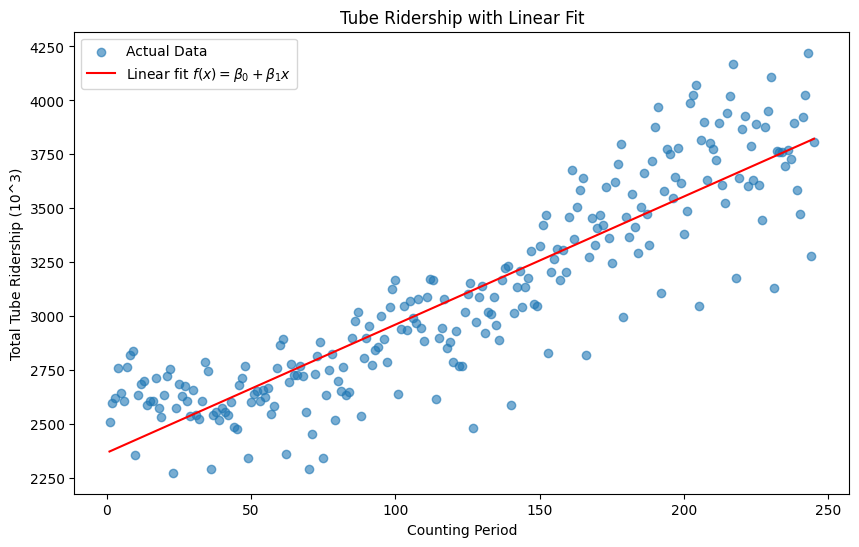

In [10]:
#linear model only so set k=1
# Prepare the data matrix for polyreg
data_mat = np.column_stack((xvals, yvals))

# Fit a linear model (k=1)
beta, fit, res = polyreg(data_mat, k=1)

# Compute metrics
mse = np.mean(res**2)
y_mean = np.mean(yvals)
SST = np.sum((yvals - y_mean)**2)
r2 = 1 - np.sum(res**2) / SST

# Print coefficients and metrics
print(f"beta0 = {beta[0]:.3f}")
print(f"beta1 = {beta[1]:.3f}")
print(f"MSE = {mse:.3f}")
print(f"R^2 = {r2:.3f}")

# Plot scatterplot and linear fit
plt.figure(figsize=(10, 6))
plt.scatter(xvals, yvals, label='Actual Data', alpha=0.6)
plt.plot(xvals, fit, color='red', label='Linear fit $f(x) = \\beta_0 + \\beta_1 x$')
plt.xlabel('Counting Period')
plt.ylabel('Total Tube Ridership (10^3)')
plt.title('Tube Ridership with Linear Fit')
plt.legend()
plt.show()



## 3c)  Plotting the residuals

- Plot the residuals on a scatterplot
- Also plot the residuals over a short duration and comment on whether you can discern any periodic components.

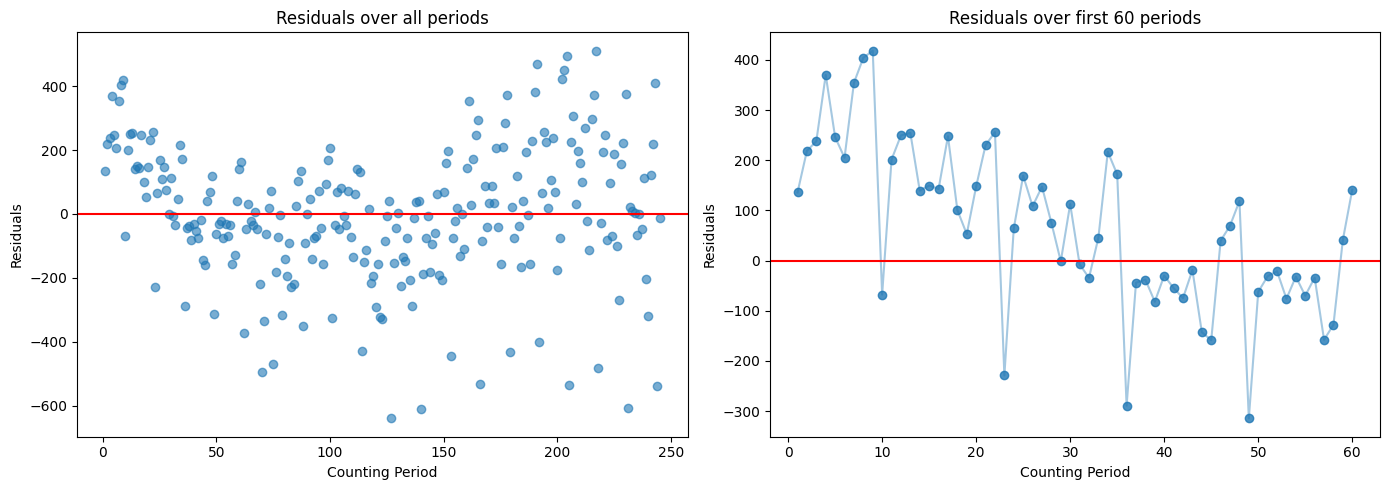

In [24]:
# Your code here
plt.figure(figsize=(14, 5))

# plot all residuals
plt.subplot(1, 2, 1)
plt.scatter(xvals, res, alpha=0.6)
plt.axhline(0, color='red')
plt.xlabel('Counting Period')
plt.ylabel('Residuals')
plt.title('Residuals over all periods')

# plot residuals over a short duration
short_duration = 60 #totally random but let's try the first 20 periods - CONFIG
plt.subplot(1, 2, 2)
plt.scatter(xvals[:short_duration], res[:short_duration], alpha=0.8)
plt.plot(xvals[:short_duration], res[:short_duration], alpha=0.4) # Line to help visualize periodicity
plt.axhline(0, color='red')
plt.xlabel('Counting Period')
plt.ylabel('Residuals')
plt.title(f'Residuals over first {short_duration} periods')

plt.tight_layout()
plt.show()


< Comment on periodic components here >


There is a very clear dip at around the 10th, 23rd, 36th, and the 49th period (approx / visually estimated). Since we started the first period in April, 10 counting period would be about 10*28 = 280 days /30.5 = 9.3 months - so these dips should correspond to the Christmas Holiday every December(?)
(13 periods would be 13*28/29 = 364-377 days so around 1 year)

This means the residual reflects seasonal patterns within the year, matching the example provided in the slides / guidance.

### 3d) Periodogram

- Compute and plot the peridogram of the residuals. (Recall that the periodogram is the squared-magnitude of the DFT coefficients.)
- Identify the indices/frequencies for which the periogram value exceeds **50%** of the maximum. 


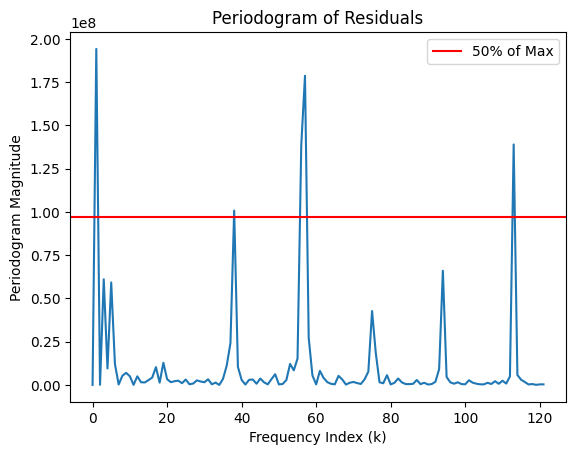

In [18]:
# Your code to compute and plot the periodogram

Y = np.fft.fft(res)
pgram = np.abs(Y)**2

# plot the first half up to N/2 because the DFT is symmetric for real-valued signals
half_N = N // 2
k_vals = np.arange(half_N)

plt.plot(k_vals, pgram[:half_N])
plt.xlabel('Frequency Index (k)')
plt.ylabel('Periodogram Magnitude')
plt.title('Periodogram of Residuals')
plt.axhline(0.5 * np.max(pgram), color='red', label='50% of Max')
plt.legend()
plt.show()



In [16]:
# Your code to identify the indices for which the periodogram value exceeds 50% of the maximum

threshold = 0.5 * np.max(pgram)
# only consider the first half (up to N/2) to avoid symmetric duplicates
dominant_indices = np.where(pgram[:half_N] > threshold)[0]

print(f"Indices exceeding 50% of max: {dominant_indices}")


Indices exceeding 50% of max: [  1  38  56  57 113]


## 3e) To the residuals,  fit a model of the form  

$$ \beta_{1s} \sin(\omega_1 x) + \beta_{1c} \cos(\omega_1 x) + \beta_{2s} \sin(\omega_2 x) + \beta_{2c} \cos(\omega_2 x) + \ldots + \beta_{Ks} \sin(\omega_K x) + \beta_{Kc} \cos(\omega_K x).$$

The frequencies $\omega_1, \ldots, \omega_K$ in the model are those corresponding to the indices identified in Part 2c. (Hint: Each of the sines and cosines will correspond to one column in your X-matrix.)

- Print the values of the regression coefficients obtained using least-squares. 

All numerical outputs should be displayed to three decimal places.

In [21]:
# Your code here

# calc. freq. corresponding to the dominant indices
omegas = 2 * np.pi * dominant_indices / N

# Create the design matrix for the trig. model
# for every identified omega: 2 cols: (sin, cos)
X_trig = np.zeros((N, 2 * len(omegas)))

for i, omega in enumerate(omegas):
    X_trig[:, 2*i] = np.sin(omega * xvals)
    X_trig[:, 2*i + 1] = np.cos(omega * xvals)

# Solve for coefficients using least-squares natively
# beta_trig = (X^T * X)^(-1) * X^T * res
X_trig_T = np.transpose(X_trig)
X_trig_T_X = np.matmul(X_trig_T, X_trig)
X_trig_T_X_inv = np.linalg.inv(X_trig_T_X)
X_trig_T_res = np.matmul(X_trig_T, res)

beta_trig = np.matmul(X_trig_T_X_inv, X_trig_T_res)

# Print the coefficients
for i, omega in enumerate(omegas):
    print(f"Frequency {dominant_indices[i]} (omega = {omega:.3f}):")
    print(f"  beta_{i+1}s (sin) = {beta_trig[2*i]:.3f}")
    print(f"  beta_{i+1}c (cos) = {beta_trig[2*i+1]:.3f}")

# Compute the trigonometric fit
fit_trig = np.matmul(X_trig, beta_trig)



Frequency 1 (omega = 0.026):
  beta_1s (sin) = -51.253
  beta_1c (cos) = 101.556
Frequency 38 (omega = 0.975):
  beta_2s (sin) = 61.628
  beta_2c (cos) = -54.006
Frequency 56 (omega = 1.436):
  beta_3s (sin) = -15.581
  beta_3c (cos) = -94.797
Frequency 57 (omega = 1.462):
  beta_4s (sin) = 81.659
  beta_4c (cos) = 72.381
Frequency 113 (omega = 2.898):
  beta_5s (sin) = 32.472
  beta_5c (cos) = 90.589


### 3f) The combined fit
- Plot the combined fit together with a scatterplot of the data
- Compute and print the final **MSE** and $R^2$ coefficient. Comment on the improvement over the linear fit.

The combined fit, which corresponds to the full model

$$
f(x) = \beta_0 + \beta_1 x + \beta_{s1} \sin(\omega_1 x) + \beta_{c1} \cos(\omega_1 x) + \ldots + \beta_{sk} \sin(\omega_k x) + \beta_{ck} \cos(\omega_k x),
$$

can be obtained by adding the fits in parts 2b) and 2e).

Combined MSE = 20297.501
Combined R^2 = 0.908


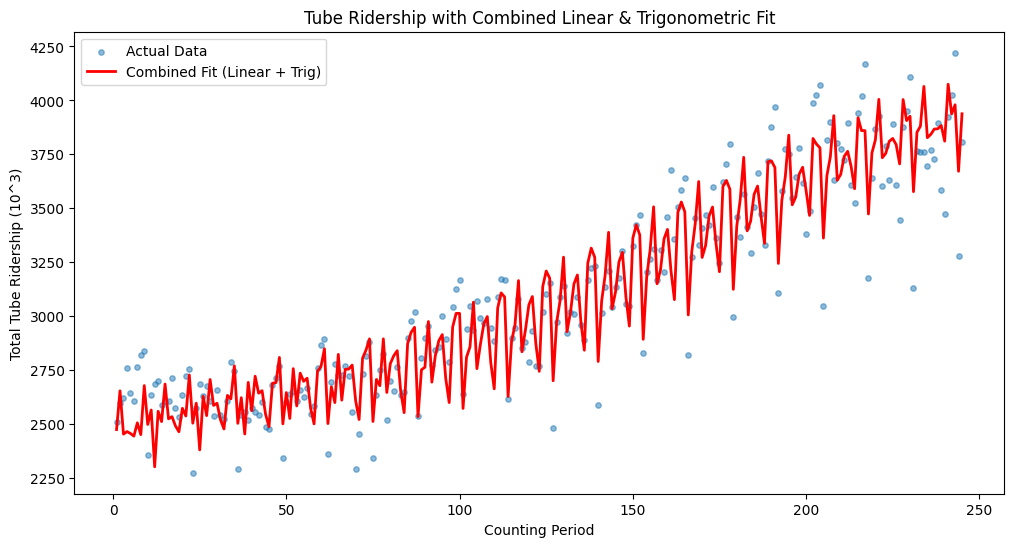

In [22]:
# Your code here

# sum linear fit and trig. fit
fit_combined = fit + fit_trig

# residuals and MSE for the combined fit
res_combined = yvals - fit_combined
mse_combined = np.mean(res_combined**2)

y_mean = np.mean(yvals)
SST = np.sum((yvals - y_mean)**2)
r2_combined = 1 - (np.sum(res_combined**2) / SST)

print(f"Combined MSE = {mse_combined:.3f}")
print(f"Combined R^2 = {r2_combined:.3f}")

# Plot combined fit
plt.figure(figsize=(12, 6))
plt.scatter(xvals, yvals, label='Actual Data', alpha=0.5, s=15)
plt.plot(xvals, fit_combined, color='red', label='Combined Fit (Linear + Trig)', linewidth=2)
plt.xlabel('Counting Period')
plt.ylabel('Total Tube Ridership (10^3)')
plt.title('Tube Ridership with Combined Linear & Trigonometric Fit')
plt.legend()
plt.show()



< Add comment on the improvement over the linear fit. >

It now reflects seasonal patterns more closely

MSE has decreased, and R^2 has increased, so the fit of the combined model is better than the linear fit model.

AI Use Statement:
LLMs have been used to assist with graph formating for certain plots. It has also been used to provide feedback and guidance regarding the mathematical concepts, and the syntax / functions of numpy and matplotlib, and debugging.